In [1]:
import pandas as pd, numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy.stats import spearmanr

In [2]:
def qced_proteins(df, protein_cols):
    tmp_df = df.copy()
    tmp_df.dropna(subset=protein_cols, inplace=True)

    for protein_col in protein_cols:    
        mean_v = tmp_df[protein_col].mean()
        std_v = tmp_df[protein_col].std()
            
        lower_bound = mean_v - 5 * std_v
        upper_bound = mean_v + 5 * std_v
            
        tmp_df = tmp_df[(tmp_df[protein_col] >= lower_bound) & (tmp_df[protein_col] <= upper_bound)]
    
    return tmp_df

# Load results from models

In [3]:
gnpc_folder = 'results/GNPC/e4vse3e3'
bf2soma_folder = 'results/BF2Somalogic/e4vse3e3'
bf2soma_ad_folder = 'results/BF2Somalogic/e4vse3e3'
adni_folder = 'results/ADNI/e4vse3e3'
adnitmt_e4_folder = 'results/ADNI_MS/e4vse3e3'
bf2olink_folder = 'results/BF2OLINK/e4vse3e3'
ukbb_folder = 'results/UKBB'

In [4]:
ukbb_apoe2protein = pd.read_csv(f"{ukbb_folder}/e4vse3e3/apoe2protein.csv")
ukbb_apoe2protein['symbol'] = ukbb_apoe2protein['Protein_id'].apply(lambda x:x.split('_')[1])
ukbb_apoe2protein['label'] = ukbb_apoe2protein['Protein_id'].apply(lambda x: x.split('_')[1])

In [5]:
gnpc_apoe2protein = pd.read_csv(f"{gnpc_folder}/apoe2protein.csv")
bf2soma_apoe2protein = pd.read_csv(f"{bf2soma_folder}/apoe2protein.csv")
bf2soma_ad_apoe2protein = pd.read_csv(f"{bf2soma_ad_folder}/apoe2protein.csv")
adni_apoe2protein = pd.read_csv(f"{adni_folder}/apoe2protein.csv")
adnitmt_apoe2protein = pd.read_csv(f"{adnitmt_e4_folder}/apoe2protein.csv")
adnitmt_apoe2protein['Protein_id'] = adnitmt_apoe2protein['symbol'] + '_' + adnitmt_apoe2protein['UniProt'] + '_MS'
bf2olink_apoe2protein = pd.read_csv(f"{bf2olink_folder}/apoe2protein.csv")

# Extended Fig. 5: Direct comparison of plasma SomaLogic vs. CSF OLINK in BioFINDER-2

## Data preprocess

In [6]:
symbolmapping = pd.read_excel('../ref/symbol_mapping_across_platform.xlsx', keep_default_na=True)
apt2symbol = dict(zip(symbolmapping['apt_name'].tolist(), symbolmapping['symbol'].tolist()))

df1 = (
    bf2soma_apoe2protein
    .sort_values('p_adjusted')
    .drop_duplicates('symbol')
)

df2 = (
    bf2olink_apoe2protein
    .sort_values('p_adjusted')
    .drop_duplicates('symbol')
)

intersection = pd.merge(df1, df2, on='symbol', how='inner')

In [7]:
somaplasma = pd.read_csv('../data/BF2Somalogic/preprocessed/with24_7285prot.csv')
csfolink = pd.read_csv("../data/BF2OLINK/preprocessed/with24_1391proteins.csv")

In [8]:
kept_soma = intersection['Protein_id_x'].tolist()
kept_soma = [f'{x.split('__')[-2]}' for x in kept_soma]
kept_olink = intersection['Protein_id_y'].tolist()

In [9]:
somaplasma_df = somaplasma[['sid','gender_baseline_variable', 'age', 'plasma_ANML_mean'] + [x for x in somaplasma.columns if x[-4:] == 'ANML' and x.split('__')[-2] in kept_soma]]
csfolink_df = csfolink[['sid','gender_baseline_variable', 'age', 'CSF_NPX_mean'] + [x for x in csfolink.columns if x in kept_olink]]

In [10]:
somaplasma_df.columns = [f'{apt2symbol[x.split('__')[-2]]}__ANML' if x[-4:] == 'ANML' else x for x in somaplasma_df.columns ]
csfolink_df.columns = [f'{x.split('__')[0]}__NPX' if x[-3:] == 'NPX' else x for x in csfolink_df.columns]

In [11]:
# regress out mean protein level
somaplasma_residuals = somaplasma_df[['sid','gender_baseline_variable', 'age', 'plasma_ANML_mean']]
for protein in [x for x in somaplasma_df.columns if x[-4:] == 'ANML']:
    tmp = somaplasma_df[[protein, 'plasma_ANML_mean']]
    hasvalue = tmp[~tmp[protein].isna()]
    novalue = tmp[tmp[protein].isna()]
    
    X = hasvalue[['plasma_ANML_mean']]
    y = hasvalue[[protein]]
    X = sm.add_constant(X)
    model = sm.OLS(y, X).fit()
    
    hasvalue[protein] = model.resid
    novalue[protein] = np.nan
    
    merged = pd.concat([hasvalue, novalue], join='inner')

    somaplasma_residuals = pd.merge(somaplasma_residuals, merged[[protein]], left_index=True, right_index=True, how='left')

In [12]:
csfolink_residuals = csfolink_df[['sid','CSF_NPX_mean']]
for protein in [x for x in csfolink_df.columns if x[-3:] == 'NPX']:
    tmp = csfolink_df[[protein, 'CSF_NPX_mean']]
    hasvalue = tmp[~tmp[protein].isna()]
    novalue = tmp[tmp[protein].isna()]
    
    X = hasvalue[['CSF_NPX_mean']]
    y = hasvalue[[protein]]
    X = sm.add_constant(X)
    model = sm.OLS(y, X).fit()
    
    hasvalue[protein] = model.resid
    novalue[protein] = np.nan
    
    merged = pd.concat([hasvalue, novalue], join='inner')

    csfolink_residuals = pd.merge(csfolink_residuals, merged[[protein]], left_index=True, right_index=True, how='left')

In [13]:
merged = pd.merge(somaplasma_residuals, csfolink_residuals, on=['sid'], how='inner')

In [15]:
len(merged.index), len(intersection)

(1349, 1169)

## Extended Fig. 5c

In [14]:
matrix = merged[[x for x in merged.columns if x[-4:] == 'ANML' or x[-3:]=='NPX']]

for col in matrix.columns:
    if pd.api.types.is_numeric_dtype(matrix[col]):
        mean = matrix[col].mean()
        std = matrix[col].std()
        upper_bound = mean + 5 * std
        lower_bound = mean - 5 * std

        matrix[col] = matrix[col].apply(lambda x: np.nan if x < lower_bound or x > upper_bound else x)
corr = matrix.corr(method='spearman')

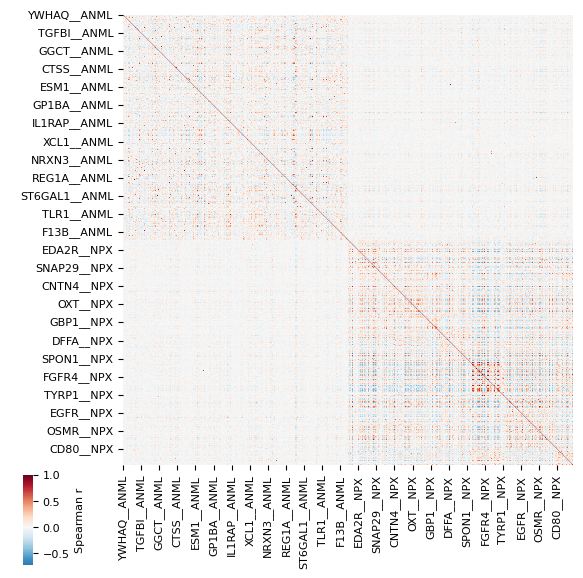

In [15]:
plt.rcParams['font.size'] = 8
g = sns.clustermap(corr,cmap='RdBu_r', col_cluster=False, row_cluster=False,
                   figsize=(5, 5),
               cbar_pos=(0.05, -0.1, 0.02, 0.18),  # (left, bottom, width, height)
               cbar=True, center=0,
               cbar_kws={'label': 'Spearman r'}) #"orientation": "horizontal", 
g.ax_heatmap.yaxis.set_ticks_position('left')
g.ax_heatmap.yaxis.set_label_position('left')

g.ax_heatmap.plot(np.arange(len(corr)), np.arange(len(corr)), color='#67001F', linewidth=0.2)

#g.fig.subplots_adjust(top=0.95, bottom=0.05, left=0, right=0.95)
g.ax_heatmap.set_position([0.25, 0.1, 0.9, 0.9])
plt.savefig("../Figs/other/plasmaSoma_vs_csfOLINK.png", dpi=1200, bbox_inches='tight')

## Extended Fig. 5d,e

In [19]:
somacols = [x for x in merged.columns if x[-4:] == 'ANML']
olinkcols = list()
userow = list()
r = list()
p = list()

for somacol in somacols:
    olinkcol = f'{somacol.split("__")[0]}__NPX'
    olinkcols.append(olinkcol)

    tmp = merged[['gender_baseline_variable', 'age', somacol, olinkcol]]

    qced = qced_proteins(tmp, [somacol, olinkcol])

    userow.append(len(qced))

    correlation, p_value = spearmanr(
        qced[somacol].tolist(), 
        qced[olinkcol].tolist(),
        nan_policy='omit'
    )

    r.append(correlation)
    p.append(p_value)

cor = pd.DataFrame({'BF2_Soma': somacols,
              'BF2_OLINK': olinkcols,
              'userow': userow,
              'r': r,
              'p': p,
              'symbol':[x.split('__')[0] for x in somacols]})

cor.to_csv('../Supplement/BF2_plasmaSoma_csfOLINK_correlation_spearman.csv', index=False)

# Extended Fig. 3: Direct comparison of SomaLogic vs. TMT-MS in ADNI (CSF)

## Data preprocess

In [16]:
symbolmapping = pd.read_excel('../ref/symbol_mapping_across_platform.xlsx', keep_default_na=True)
apt2symbol = dict(zip(symbolmapping['apt_name'].tolist(), symbolmapping['symbol'].tolist()))

df1 = (
    adni_apoe2protein
    .sort_values('p_adjusted')
    .drop_duplicates('symbol')
)

df2 = (
    adnitmt_apoe2protein
    .sort_values('p_adjusted')
    .drop_duplicates('symbol')
)
intersection = pd.merge(df1, df2, on='symbol', how='inner')

In [17]:
adni = pd.read_csv("../data/ADNI/preprocessed/adni_soma_ms_merged.csv")

/var/folders/81/ddj0xhs55bg3d4mpqcms0bjw0000gp/T/ipykernel_4703/1399229885.py:1: DtypeWarning: Columns (0: AB_PET_status) have mixed types. Specify dtype option on import or set low_memory=False.
  adni = pd.read_csv("../data/ADNI/preprocessed/adni_soma_ms_merged.csv")


In [18]:
kept_soma = intersection['Protein_id_x'].tolist()
kept_soma = [f'{x.split('__')[-2]}' for x in kept_soma]
kept_tmt = intersection['Protein_id_y'].tolist()

In [19]:
soma_df = adni[['RID','AGE', 'PTGENDER', 'CSF_ANML_mean'] + [x for x in adni.columns if x[-4:] == 'ANML' and x.split('__')[-2] in kept_soma]]
tmt_df = adni[['RID','AGE', 'PTGENDER', 'CSF_TMT_mean'] + [x for x in adni.columns if x in kept_tmt]]

In [20]:
soma_df.columns = [f'{apt2symbol[x.split("__")[-2]]}__ANML' if x[-4:] == 'ANML' else x for x in soma_df.columns ]
tmt_df.columns = [f'{x.split("_")[0]}__TMT' if x[-2:] == 'MS' else x for x in tmt_df.columns]

# Protein ~ mean protein level
#### Results remain similar with or without using the residuals

In [21]:
# regress out mean protein level
soma_df_residuals = soma_df[['RID','AGE', 'PTGENDER', 'CSF_ANML_mean']]
for protein in [x for x in soma_df.columns if x[-4:] == 'ANML']:
    tmp = soma_df[[protein, 'CSF_ANML_mean']]
    hasvalue = tmp[~tmp[protein].isna()]
    novalue = tmp[tmp[protein].isna()]
    
    X = hasvalue[['CSF_ANML_mean']]
    y = hasvalue[[protein]]
    X = sm.add_constant(X)
    model = sm.OLS(y, X).fit()
    
    hasvalue[protein] = model.resid
    novalue[protein] = np.nan
    
    merged = pd.concat([hasvalue, novalue], join='inner')

    soma_df_residuals = pd.merge(soma_df_residuals, merged[[protein]], left_index=True, right_index=True, how='left')

In [22]:
tmt_residuals = tmt_df[['RID','CSF_TMT_mean']]
for protein in [x for x in tmt_df.columns if x[-3:] == 'TMT']:
    tmp = tmt_df[[protein, 'CSF_TMT_mean']]
    hasvalue = tmp[~tmp[protein].isna()]
    novalue = tmp[tmp[protein].isna()]
    
    X = hasvalue[['CSF_TMT_mean']]
    y = hasvalue[[protein]]
    X = sm.add_constant(X)
    model = sm.OLS(y, X).fit()
    
    hasvalue[protein] = model.resid
    novalue[protein] = np.nan
    
    merged = pd.concat([hasvalue, novalue], join='inner')

    tmt_residuals = pd.merge(tmt_residuals, merged[[protein]], left_index=True, right_index=True, how='left')

In [23]:
merged = pd.merge(soma_df_residuals, tmt_residuals, on=['RID'], how='inner')

In [24]:
len(merged.index), len(intersection)

(542, 1360)

## Extended Fig. 3b

In [32]:
matrix = merged[[x for x in merged.columns if x[-4:] == 'ANML' or x[-3:]=='TMT']]

for col in matrix.columns:
    if pd.api.types.is_numeric_dtype(matrix[col]):
        mean = matrix[col].mean()
        std = matrix[col].std()
        upper_bound = mean + 5 * std
        lower_bound = mean - 5 * std

        matrix[col] = matrix[col].apply(lambda x: np.nan if x < lower_bound or x > upper_bound else x)
corr = matrix.corr(method='spearman')

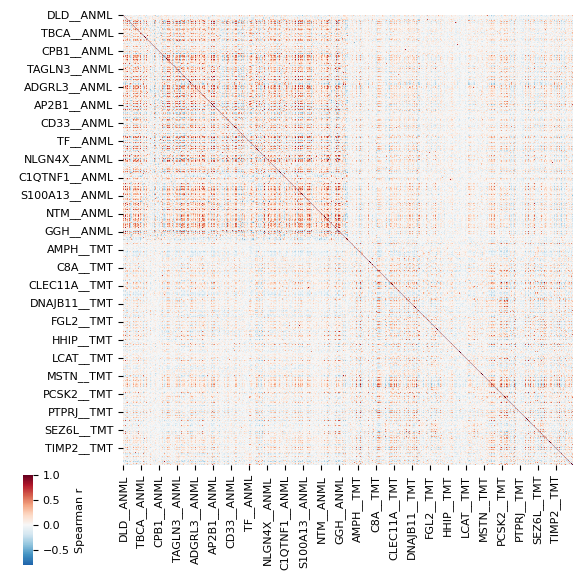

In [ ]:
plt.rcParams['font.size'] = 8
g = sns.clustermap(corr,cmap='RdBu_r', col_cluster=False, row_cluster=False,
                   figsize=(5, 5),
               cbar_pos=(0.05, -0.1, 0.02, 0.18),  # (left, bottom, width, height)
               cbar=True, center=0,
               cbar_kws={'label': 'Spearman r'}) #"orientation": "horizontal", 
g.ax_heatmap.yaxis.set_ticks_position('left')
g.ax_heatmap.yaxis.set_label_position('left')

g.ax_heatmap.plot(np.arange(len(corr)), np.arange(len(corr)), color='#67001F', linewidth=0.2)

#g.fig.subplots_adjust(top=0.95, bottom=0.05, left=0, right=0.95)
g.ax_heatmap.set_position([0.25, 0.1, 0.9, 0.9])
plt.savefig("../Figs/other/tmt_vs_soma.png", dpi=1200, bbox_inches='tight')

## Extended Fig. 3c,d

In [34]:
somacols = [x for x in merged.columns if x[-4:] == 'ANML']
tmtcols = list()
userow = list()
r = list()
p = list()

for somacol in somacols:
    tmtcol = f'{somacol.split("__")[0]}__TMT'
    tmtcols.append(tmtcol)

    tmp = merged[[somacol, tmtcol]]

    qced = qced_proteins(tmp, [somacol, tmtcol])
    userow.append(len(qced))

    correlation, p_value = spearmanr(
        qced[somacol].tolist(), 
        qced[tmtcol].tolist(),
        nan_policy='omit'
    )

    r.append(correlation)
    p.append(p_value)

cor = pd.DataFrame({'ADNI_Soma': somacols,
              'ADNI_TMT': tmtcols,
              'userow': userow,
              'r': r,
              'p': p,
              'symbol':[x.split('__')[0] for x in somacols]})

cor.to_csv('../Supplement/ADNI_CSFSoma_TMT_correlation_spearman.csv', index=False)